First we want to create our dataset using the open meteo tool https://open-meteo.com/en/docs


In [1]:
import openmeteo_requests
import requests_cache
import pandas as pd
from retry_requests import retry
import time
import os
import glob
import kagglehub
from matplotlib import pyplot as plt
import seaborn as sns

c:\Users\morit\miniconda3\envs\Genome_analysis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("guillemservera/global-daily-climate-data")

print("Path to dataset files:", path)

# countries.csv  →  one row per country, includes capital name + coordinates
# cities.csv     →  one row per weather station (station_id, lat, lon, country)
# daily_weather.parquet  →  daily readings linked by station_id
countries_df = pd.read_csv(f"{path}/countries.csv")
cities_df    = pd.read_csv(f"{path}/cities.csv")
Daily_weather_df = pd.read_parquet(f"{path}/daily_weather.parquet")

print(f"\ncountries_df: {countries_df['country'].nunique()} rows — {countries_df.columns.tolist()}")
print(f"cities_df   : {len(cities_df)} rows — {cities_df.columns.tolist()}")
print (f"countries in cities_df: {cities_df['country'].nunique()}")
print (f"countries in cities_df but not in countries_df: {set(cities_df['country'].unique()) - set(countries_df['country'].unique())}")
print(f"Daily_weather_df: {len(Daily_weather_df)} rows — {Daily_weather_df.columns.tolist()}")

Path to dataset files: C:\Users\morit\.cache\kagglehub\datasets\guillemservera\global-daily-climate-data\versions\20

countries_df: 214 rows — ['country', 'native_name', 'iso2', 'iso3', 'population', 'area', 'capital', 'capital_lat', 'capital_lng', 'region', 'continent']
cities_df   : 1245 rows — ['station_id', 'city_name', 'country', 'state', 'iso2', 'iso3', 'latitude', 'longitude']
countries in cities_df: 216
countries in cities_df but not in countries_df: {'Svalbard and Jan Mayen Islands', 'Congo (Kinshasa)', 'Guinea Bissau', 'Macau S.A.R', 'Andorra', 'Congo (Brazzaville)', 'Montenegro', 'Myanmar', 'United States of America'}
Daily_weather_df: 27635763 rows — ['station_id', 'city_name', 'date', 'season', 'avg_temp_c', 'min_temp_c', 'max_temp_c', 'precipitation_mm', 'snow_depth_mm', 'avg_wind_dir_deg', 'avg_wind_speed_kmh', 'peak_wind_gust_kmh', 'avg_sea_level_pres_hpa', 'sunshine_total_min']


In [3]:
print (Daily_weather_df.head())
#add a year column to the daily weather dataframe
print (Daily_weather_df["date"].max())


  station_id city_name       date  season  avg_temp_c  min_temp_c  max_temp_c  \
0      41515  Asadabad 1957-07-01  Summer        27.0        21.1        35.6   
1      41515  Asadabad 1957-07-02  Summer        22.8        18.9        32.2   
2      41515  Asadabad 1957-07-03  Summer        24.3        16.7        35.6   
3      41515  Asadabad 1957-07-04  Summer        26.6        16.1        37.8   
4      41515  Asadabad 1957-07-05  Summer        30.8        20.0        41.7   

   precipitation_mm  snow_depth_mm  avg_wind_dir_deg  avg_wind_speed_kmh  \
0               0.0            NaN               NaN                 NaN   
1               0.0            NaN               NaN                 NaN   
2               1.0            NaN               NaN                 NaN   
3               4.1            NaN               NaN                 NaN   
4               0.0            NaN               NaN                 NaN   

   peak_wind_gust_kmh  avg_sea_level_pres_hpa  sunshine_

In [4]:
# 1. Extract year and aggregate to yearly
yearly_weather_df = Daily_weather_df.copy()
yearly_weather_df['year'] = pd.to_datetime(yearly_weather_df['date']).dt.year

print (yearly_weather_df.head())

  station_id city_name       date  season  avg_temp_c  min_temp_c  max_temp_c  \
0      41515  Asadabad 1957-07-01  Summer        27.0        21.1        35.6   
1      41515  Asadabad 1957-07-02  Summer        22.8        18.9        32.2   
2      41515  Asadabad 1957-07-03  Summer        24.3        16.7        35.6   
3      41515  Asadabad 1957-07-04  Summer        26.6        16.1        37.8   
4      41515  Asadabad 1957-07-05  Summer        30.8        20.0        41.7   

   precipitation_mm  snow_depth_mm  avg_wind_dir_deg  avg_wind_speed_kmh  \
0               0.0            NaN               NaN                 NaN   
1               0.0            NaN               NaN                 NaN   
2               1.0            NaN               NaN                 NaN   
3               4.1            NaN               NaN                 NaN   
4               0.0            NaN               NaN                 NaN   

   peak_wind_gust_kmh  avg_sea_level_pres_hpa  sunshine_

In [5]:
#due to otherwise error in aggregation, we need to convert the city_name and year columns to string and int respectively
print(yearly_weather_df[[ "station_id", "city_name", "year"]].dtypes)

yearly_weather_df["city_name"] = yearly_weather_df["city_name"].astype(str)
yearly_weather_df["year"]      = yearly_weather_df["year"].astype(int)

station_id    category
city_name     category
year             int32
dtype: object


In [6]:
#check for nan values
print(yearly_weather_df.isna().sum())
#very high amount of nan values in all columns, most likely in the early measurment years




station_id                       0
city_name                    13993
date                             0
season                           0
avg_temp_c                 6230907
min_temp_c                 5718229
max_temp_c                 5539346
precipitation_mm           6642500
snow_depth_mm             24208615
avg_wind_dir_deg          24183195
avg_wind_speed_kmh        22350295
peak_wind_gust_kmh        26514277
avg_sea_level_pres_hpa    23618606
sunshine_total_min        26614302
year                             0
dtype: int64


   year  nan_count
0  1957    1465934
1  1958    1541662
2  1961    1604759
3  1962    1582385
4  1973    2075238


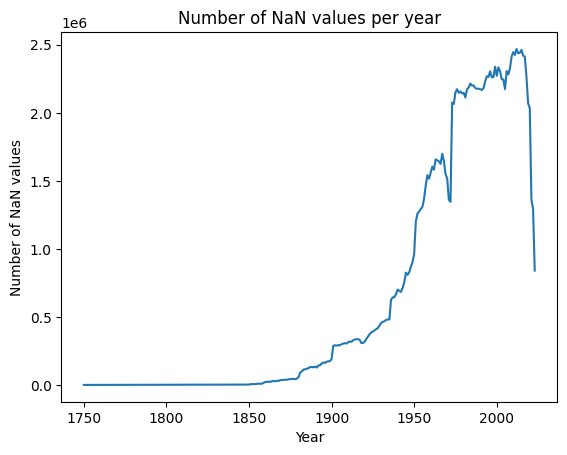

In [7]:
#check the amount of nan values per year
nan_values = []
for i in yearly_weather_df["year"].unique():
    nan_count = yearly_weather_df[yearly_weather_df['year'] == i].isna().sum().sum()
    nan_values.append(nan_count)
    

nan_values_df = pd.DataFrame({"year": yearly_weather_df["year"].unique(), "nan_count": nan_values})
print(nan_values_df.head())

sns.lineplot(data=nan_values_df, x="year", y="nan_count")
plt.title("Number of NaN values per year")
plt.xlabel("Year")
plt.ylabel("Number of NaN values")
plt.show()
#interestingly the amount of non values starts low and then increases over time, which is the opposite of what we would expect. 
# This could be due to a change in the way the data was collected or recorded, or it could be an issue with the dataset itself. Further investigation would be needed to determine the cause of this trend.

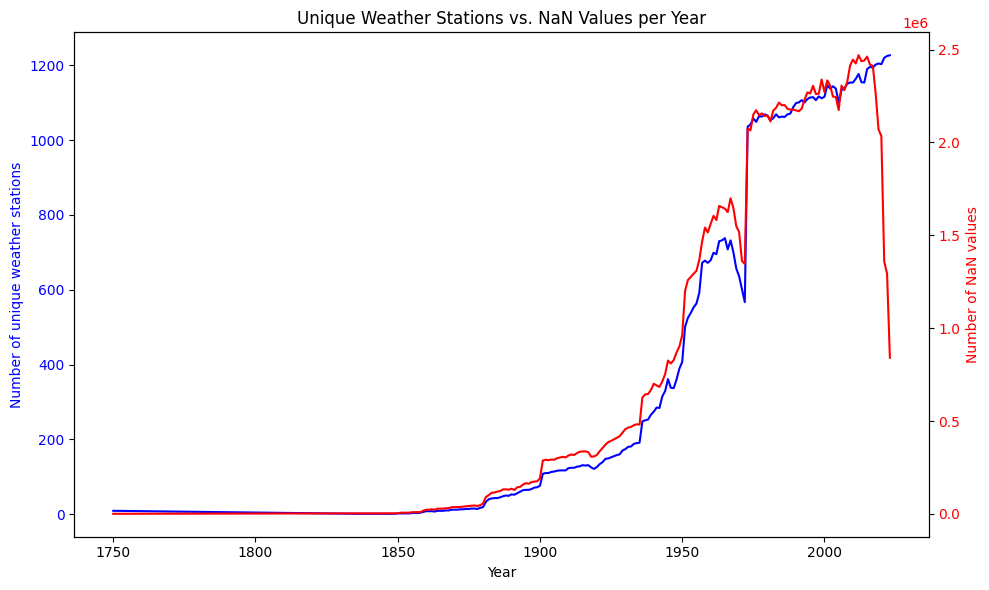

In [8]:
#plot the amount of weather stations per year
station_counts = yearly_weather_df.groupby('year')['station_id'].nunique()

# 1. Initialize the figure and primary axis explicitly
fig, ax1 = plt.subplots(figsize=(10, 6))

# 2. Plot the first dataset on the primary axis (ax1)
sns.lineplot(
    x=station_counts.index, 
    y=station_counts.values, 
    color="blue", 
    ax=ax1
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of unique weather stations", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")

# 3. Create the second axis sharing the same x-axis
ax2 = ax1.twinx()

# 4. Plot the second dataset on the secondary axis (ax2)
sns.lineplot(
    x=nan_values_df["year"], 
    y=nan_values_df["nan_count"], 
    color="red", 
    ax=ax2
)
ax2.set_ylabel("Number of NaN values", color="red")
ax2.tick_params(axis='y', labelcolor="red")

# 5. Set the title and render
plt.title("Unique Weather Stations vs. NaN Values per Year")
plt.tight_layout()
plt.show()
#this explains the increase in nan values over time, as more weather stations were added to the dataset, there were more opportunities for missing data to occur. 
# Additionally, it is possible that the data collection methods improved over time, leading to more complete records in later years.

In [9]:
#percent nan values per column
nan_percentages = yearly_weather_df.isna().mean() * 100
print(nan_percentages)
#we see that weather variables like temperature and precipitation have a very high percentage of missing values,
#  while the station_id and city_name columns are mostly complete. 

station_id                 0.000000
city_name                  0.050634
date                       0.000000
season                     0.000000
avg_temp_c                22.546535
min_temp_c                20.691410
max_temp_c                20.044122
precipitation_mm          24.035884
snow_depth_mm             87.598866
avg_wind_dir_deg          87.506884
avg_wind_speed_kmh        80.874536
peak_wind_gust_kmh        95.941903
avg_sea_level_pres_hpa    85.463919
sunshine_total_min        96.303844
year                       0.000000
dtype: float64


In [10]:
#check for nan values percentages in 2000
nan_2000 = yearly_weather_df[yearly_weather_df['year'] == 2000].isna().mean() * 100
print(nan_2000)
#even in later years like 2000, we still see a high percentage of missing values in the weather variables,
# which suggests that the issue of missing data is persistent throughout the dataset and not just limited to the earlier years. 

station_id                 0.000000
city_name                  0.101316
date                       0.000000
season                     0.000000
avg_temp_c                 3.539970
min_temp_c                18.836195
max_temp_c                14.833382
precipitation_mm          46.017395
snow_depth_mm             86.994181
avg_wind_dir_deg          91.797003
avg_wind_speed_kmh        82.670258
peak_wind_gust_kmh        98.180741
avg_sea_level_pres_hpa    89.597393
sunshine_total_min        96.338229
year                       0.000000
dtype: float64


In [11]:
#due to this we will drop snowdepth,winddirection,sea_levels and sunshine_duration columns, as they have the highest percentage of missing values and are not essential for our analysis.
yearly_weather_df = yearly_weather_df.drop(columns=["snow_depth_mm", "avg_wind_dir_deg", "avg_wind_speed_kmh", "avg_sea_level_pres_hpa", "sunshine_total_min","precipitation_mm","peak_wind_gust_kmh"])
print(yearly_weather_df.columns.tolist())

['station_id', 'city_name', 'date', 'season', 'avg_temp_c', 'min_temp_c', 'max_temp_c', 'year']


In [12]:
#cities_df has station_id + country (or country_code)
# Add country to yearly weather df
yearly_weather_df = yearly_weather_df.merge(
    cities_df[["station_id", "country", "latitude", "longitude"]],
    on="station_id",
    how="inner"
)

print(yearly_weather_df.head())




  station_id city_name       date  season  avg_temp_c  min_temp_c  max_temp_c  \
0      41515  Asadabad 1957-07-01  Summer        27.0        21.1        35.6   
1      41515  Asadabad 1957-07-02  Summer        22.8        18.9        32.2   
2      41515  Asadabad 1957-07-03  Summer        24.3        16.7        35.6   
3      41515  Asadabad 1957-07-04  Summer        26.6        16.1        37.8   
4      41515  Asadabad 1957-07-05  Summer        30.8        20.0        41.7   

   year      country  latitude  longitude  
0  1957  Afghanistan    34.866  71.150005  
1  1957  Afghanistan    34.866  71.150005  
2  1957  Afghanistan    34.866  71.150005  
3  1957  Afghanistan    34.866  71.150005  
4  1957  Afghanistan    34.866  71.150005  


In [13]:


#groupby yearly weather, we take country, city_name, year, latitude and longitude as the grouping columns because they are strings,
#  and then we aggregate the other columns using mean for temperature and wind speed, sum for precipitation and sunshine hours, and mean for pressure and snow depth. Finally, we reset the index to get a clean dataframe.
weather_yearly = yearly_weather_df.groupby(
    ["country", "city_name", "year", "latitude", "longitude"]
).agg(
    temp_mean        = ("avg_temp_c",             "mean"),
    temp_min         = ("min_temp_c",             "mean"),
    temp_max         = ("max_temp_c",             "mean"),
).reset_index()

print(weather_yearly.head())


       country city_name  year  latitude  longitude  temp_mean   temp_min  \
0  Afghanistan  Asadabad  1957    34.866  71.150005  18.167391  12.645714   
1  Afghanistan  Asadabad  1958    34.866  71.150005  16.907945  12.071384   
2  Afghanistan  Asadabad  1961    34.866  71.150005  20.255000  14.503571   
3  Afghanistan  Asadabad  1962    34.866  71.150005  15.402247   9.534118   
4  Afghanistan  Asadabad  1973    34.866  71.150005   8.753846   1.333333   

    temp_max  
0  26.255307  
1  24.443343  
2  27.846552  
3  23.133721  
4  14.000000  


In [14]:
yearly_weather_df.drop(columns=["station_id", "city_name", "latitude", "longitude"], inplace=True)
yearly_weather_df = yearly_weather_df.groupby(['country', 'year']).mean(numeric_only=True).reset_index()

# ← ADD THE FULL RENAME_MAP HERE
rename_map = {
    "Congo (Kinshasa)":         "Democratic Republic of Congo",
    "Congo (Brazzaville)":      "Congo",
    "Guinea Bissau":            "Guinea-Bissau",
    "Czech Republic":           "Czechia",
    "Macedonia":                "North Macedonia",
    "Macau S.A.R":              "Macao",
    "Ivory Coast":              "Cote d'Ivoire",
    "United States of America": "United States",
    "The Gambia":               "Gambia",
    "The Bahamas":              "Bahamas",
    "Swaziland":                "Eswatini",
    "São Tomé and Príncipe":    "Sao Tome and Principe",
}
yearly_weather_df["country"] = yearly_weather_df["country"].replace(rename_map)

# Merge back capital coordinates
yearly_weather_df = yearly_weather_df.merge(
    countries_df[['country', 'capital_lat', 'capital_lng']],
    on='country',
    how='left'
)

print(yearly_weather_df.head())

       country  year  avg_temp_c  min_temp_c  max_temp_c  capital_lat  \
0  Afghanistan  1898    5.500000         NaN         NaN    34.526011   
1  Afghanistan  1899    8.513218         NaN         NaN    34.526011   
2  Afghanistan  1900    9.410556         NaN         NaN    34.526011   
3  Afghanistan  1901    9.162011         NaN         NaN    34.526011   
4  Afghanistan  1902    8.589589         NaN         NaN    34.526011   

   capital_lng  
0    69.177684  
1    69.177684  
2    69.177684  
3    69.177684  
4    69.177684  


In [15]:
#add to the dataset CO2 emissions data per capital from https://ourworldindata.org/grapher/co-emissions-per-capita

co2_emission = pd.read_csv (f"Data/co-emissions-per-capita.csv")
print (co2_emission.head())
print (co2_emission.tail())




        Entity Code  Year  CO₂ emissions per capita
0  Afghanistan  AFG  1949                  0.001992
1  Afghanistan  AFG  1950                  0.010837
2  Afghanistan  AFG  1951                  0.011625
3  Afghanistan  AFG  1952                  0.011468
4  Afghanistan  AFG  1953                  0.013123
         Entity Code  Year  CO₂ emissions per capita
26504  Zimbabwe  ZWE  2020                  0.546847
26505  Zimbabwe  ZWE  2021                  0.647125
26506  Zimbabwe  ZWE  2022                  0.761205
26507  Zimbabwe  ZWE  2023                  0.822681
26508  Zimbabwe  ZWE  2024                  0.823666


In [16]:
#change names of columns in co2_emission to match with yearly_weather_df


yearly_weather_df["country"] = yearly_weather_df["country"].replace(rename_map)


In [17]:
#merge the co2_emission dataframe with the yearly_weather_df dataframe on the city and year columns
yearly_weather_df = yearly_weather_df.merge(co2_emission [['Entity', 'Year', "CO₂ emissions per capita","Code"]], left_on=['country', 'year'], right_on=['Entity', 'Year'], how='left')
yearly_weather_df = yearly_weather_df.drop(columns=["Entity", "Year"])
yearly_weather_df = yearly_weather_df.rename(columns={"CO₂ emissions per capita": "co2_per_capita"})

print (yearly_weather_df.head())
print (f"countries merged: {yearly_weather_df['country'].nunique()}")
#note that the co2 dataset starts from 1950, so we have a lot of missing values for the earlier years. 
# We will need to handle these missing values in our analysis, either by imputing them or by excluding those years from certain analyses.

       country  year  avg_temp_c  min_temp_c  max_temp_c  capital_lat  \
0  Afghanistan  1898    5.500000         NaN         NaN    34.526011   
1  Afghanistan  1899    8.513218         NaN         NaN    34.526011   
2  Afghanistan  1900    9.410556         NaN         NaN    34.526011   
3  Afghanistan  1901    9.162011         NaN         NaN    34.526011   
4  Afghanistan  1902    8.589589         NaN         NaN    34.526011   

   capital_lng  co2_per_capita Code  
0    69.177684             NaN  NaN  
1    69.177684             NaN  NaN  
2    69.177684             NaN  NaN  
3    69.177684             NaN  NaN  
4    69.177684             NaN  NaN  
countries merged: 216


In [18]:
#check the amount of missing values in the co2_per_capita column after 1950
co2_nan_percentages = yearly_weather_df[yearly_weather_df['year'] >= 1950]['co2_per_capita'].isna().mean() * 100
print(f"Percentage of NaN values in co2_per_capita column after 1950: {co2_nan_percentages:.2f}%")
#print in which countries we have the most missing values in the co2_per_capita column after 1950
co2_nan_by_country = yearly_weather_df[yearly_weather_df['year'] >= 1950].groupby('country')['co2_per_capita'].apply(lambda x: x.isna().mean() * 100).reset_index()
print(co2_nan_by_country[co2_nan_by_country['co2_per_capita'] > 0].sort_values(by='co2_per_capita', ascending=False))

Percentage of NaN values in co2_per_capita column after 1950: 11.04%
                                 country  co2_per_capita
3                         American Samoa      100.000000
40                      Christmas Island      100.000000
35                        Cayman Islands      100.000000
64                      Falkland Islands      100.000000
101                               Jersey      100.000000
96                           Isle of Man      100.000000
82                              Guernsey      100.000000
80                                  Guam      100.000000
76                             Gibraltar      100.000000
70   French Southern and Antarctic Lands      100.000000
68                         French Guiana      100.000000
212                       Western Sahara      100.000000
180                        South Georgia      100.000000
162                              Réunion      100.000000
167                           San Marino      100.000000
157                

In [19]:
#the columns with 100% missing values in the co2_per_capita column are mostly small island nations and some African countries, which may not have had consistent data collection for CO2 emissions.
yearly_weather_df = yearly_weather_df.groupby('country').filter(lambda x: x['co2_per_capita'].notna().any())
#here we filter any countries where at least one value in the co2_per_capita column is not missing, which means we keep only those countries that have at least some data on CO2 emissions. This allows us to focus our analysis on countries with available data and avoid issues with completely missing values.

print(yearly_weather_df.head(2))
#remaining missing values per country after dropping those with 100% missing values in percentages
print(yearly_weather_df.groupby('country')['co2_per_capita'].apply(lambda x: (x.isna().sum() / len(x)) * 100).sort_values(ascending=False))

       country  year  avg_temp_c  min_temp_c  max_temp_c  capital_lat  \
0  Afghanistan  1898    5.500000         NaN         NaN    34.526011   
1  Afghanistan  1899    8.513218         NaN         NaN    34.526011   

   capital_lng  co2_per_capita Code  
0    69.177684             NaN  NaN  
1    69.177684             NaN  NaN  
country
Bhutan           90.909091
Lesotho          75.886525
Namibia          70.270270
Anguilla         60.465116
Liechtenstein    52.898551
                   ...    
Vanuatu           0.000000
Vietnam           0.000000
Yemen             0.000000
Zambia            0.000000
Zimbabwe          0.000000
Name: co2_per_capita, Length: 195, dtype: float64


In [20]:
#remaining missing values per country after dropping those with 100% missing values  
print (yearly_weather_df[yearly_weather_df['year'] > 1950]["co2_per_capita"].isna().sum()/len(yearly_weather_df[yearly_weather_df['year'] > 1950])*100)
#we now have a only 2.19% missing values in the co2_per_capira column



2.199703410776075


In [21]:
#add Population data over the years from the population density dataset from the world bank https://ourworldindata.org/grapher/population-density-of-the-capital-city
population_density = pd.read_csv (f"Data/population-density-of-the-capital-city.csv")
population_density = population_density.rename(columns={"Population density of the capital city": "Cap_density","Population density of the capital city (projected) (Projected)":"Cap_density_projected"})
print (population_density.head())

        Entity Code  Year  Cap_density  Cap_density_projected  \
0  Afghanistan  AFG  1975    3853.8767                    NaN   
1  Afghanistan  AFG  1980    5159.2120                    NaN   
2  Afghanistan  AFG  1985    6376.2510                    NaN   
3  Afghanistan  AFG  1990    8000.0570                    NaN   
4  Afghanistan  AFG  1995    8951.3150                    NaN   

  Population density of the capital city (Annotations)  \
0                                              Kabul     
1                                              Kabul     
2                                              Kabul     
3                                              Kabul     
4                                              Kabul     

  Population density of the capital city (projected) (Annotations)  
0                                                NaN                
1                                                NaN                
2                                                NaN 

In [22]:
#merge the population_density dataframe with the yearly_weather_df dataframe on the city and year columns
yearly_weather_df = yearly_weather_df.merge(population_density [['Entity', 'Year', 'Cap_density']], left_on=['country', 'year'], right_on=['Entity', 'Year'], how='left')
yearly_weather_df = yearly_weather_df.drop(columns=["Entity", "Year"])
print (yearly_weather_df.head())
print (f"countries merged: {yearly_weather_df['country'].nunique()}")

       country  year  avg_temp_c  min_temp_c  max_temp_c  capital_lat  \
0  Afghanistan  1898    5.500000         NaN         NaN    34.526011   
1  Afghanistan  1899    8.513218         NaN         NaN    34.526011   
2  Afghanistan  1900    9.410556         NaN         NaN    34.526011   
3  Afghanistan  1901    9.162011         NaN         NaN    34.526011   
4  Afghanistan  1902    8.589589         NaN         NaN    34.526011   

   capital_lng  co2_per_capita Code  Cap_density  
0    69.177684             NaN  NaN          NaN  
1    69.177684             NaN  NaN          NaN  
2    69.177684             NaN  NaN          NaN  
3    69.177684             NaN  NaN          NaN  
4    69.177684             NaN  NaN          NaN  
countries merged: 195


In [23]:
#since the population density set measures every 5 years, we will have many missing values in the population density columns. We can fill these missing values using linear interpolation for each country separately.
yearly_weather_df = yearly_weather_df.sort_values(['country', 'year'])

yearly_weather_df['Cap_density'] = (
    yearly_weather_df
    .groupby('country')['Cap_density']
    .transform(lambda x: x.interpolate(method='linear'))
)

print (yearly_weather_df.head())
print (yearly_weather_df.isna().sum())

       country  year  avg_temp_c  min_temp_c  max_temp_c  capital_lat  \
0  Afghanistan  1898    5.500000         NaN         NaN    34.526011   
1  Afghanistan  1899    8.513218         NaN         NaN    34.526011   
2  Afghanistan  1900    9.410556         NaN         NaN    34.526011   
3  Afghanistan  1901    9.162011         NaN         NaN    34.526011   
4  Afghanistan  1902    8.589589         NaN         NaN    34.526011   

   capital_lng  co2_per_capita Code  Cap_density  
0    69.177684             NaN  NaN          NaN  
1    69.177684             NaN  NaN          NaN  
2    69.177684             NaN  NaN          NaN  
3    69.177684             NaN  NaN          NaN  
4    69.177684             NaN  NaN          NaN  
country              0
year                 0
avg_temp_c        3771
min_temp_c        1348
max_temp_c        1547
capital_lat        808
capital_lng        808
co2_per_capita    1277
Code              1277
Cap_density       8164
dtype: int64


In [24]:
#test the amount of missing values in the Cap_density column after interpolation per country
#the dataset starts in 1975, so we will only check for missing values after 1975 in percentages
print (f"sum of nan values in Cap_density column after interpolation: {yearly_weather_df[yearly_weather_df['year'] > 1975]['Cap_density'].isna().sum()/len(yearly_weather_df[yearly_weather_df['year'] > 1975])*100}%")
cap_density_nan_by_country = yearly_weather_df[yearly_weather_df['year'] > 1975].groupby('country')['Cap_density'].apply(lambda x: x.isna().mean() * 100).reset_index()
print(yearly_weather_df.groupby('country')["Cap_density"].apply(lambda x: (x.isna().sum() / len(x)) * 100).sort_values(ascending=False))
#we could succesfully reduce Na values to 3.8%

sum of nan values in Cap_density column after interpolation: 16.43419572553431%
country
Antigua and Barbuda             100.000000
Anguilla                        100.000000
Andorra                         100.000000
Dominica                        100.000000
Eswatini                        100.000000
                                   ...    
Albania                           3.921569
Lebanon                           3.333333
East Timor                        2.325581
Guatemala                         2.000000
Democratic Republic of Congo      0.000000
Name: Cap_density, Length: 195, dtype: float64


In [25]:
#we drop the 18 countries with 100% missing values since they arent present in the pop density dataset and they arent important countries for our analysis, as they are mostly small island nations and some African countries that may not have had consistent data collection for population density.
countries_no_pop = (
    yearly_weather_df
    .groupby('country')['Cap_density']
    .apply(lambda x: x.isna().all())
    .pipe(lambda s: s[s].index)
)
yearly_weather_df = yearly_weather_df[~yearly_weather_df['country'].isin(countries_no_pop)]
print (f"missing values in Cap_density column after dropping countries with 100% missing values: {yearly_weather_df[yearly_weather_df['year'] > 1975]['Cap_density'].isna().sum()/len(yearly_weather_df[yearly_weather_df['year'] > 1975])*100}%")
print(yearly_weather_df.groupby('country')["Cap_density"].apply(lambda x: (x.isna().sum() / len(x)) * 100).sort_values(ascending=False))
#sum of countries remaining
print (f"countries remaining after dropping those with 100% missing values in Cap_density column: {yearly_weather_df['country'].nunique()}")

missing values in Cap_density column after dropping countries with 100% missing values: 3.831715210355987%
country
Myanmar                         94.736842
Bhutan                          93.939394
Botswana                        86.407767
Brunei                          78.571429
Belgium                         74.345550
                                  ...    
Fiji                             3.921569
Lebanon                          3.333333
East Timor                       2.325581
Guatemala                        2.000000
Democratic Republic of Congo     0.000000
Name: Cap_density, Length: 168, dtype: float64
countries remaining after dropping those with 100% missing values in Cap_density column: 168


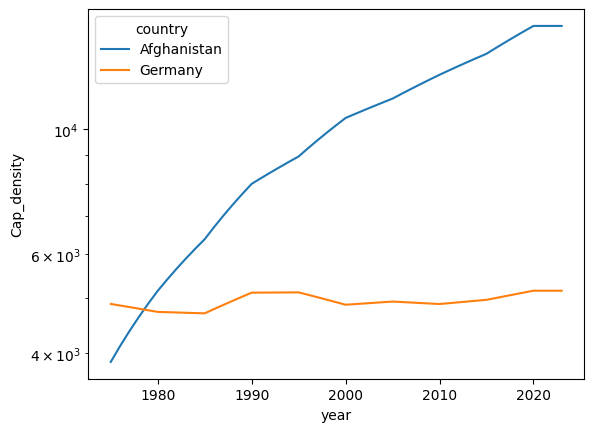

In [26]:
# 1. Filter the data efficiently in one go
target_countries = ['Germany', 'Afghanistan']
plot_data = yearly_weather_df[yearly_weather_df['country'].isin(target_countries)]

# 2. Let Seaborn handle the logic (Hue handles the legend/colors automatically)
sns.lineplot(
    data=plot_data, 
    x="year", 
    y="Cap_density", 
    hue="country"
)

plt.yscale('log')
plt.show()


In [27]:
#savce the dataset as a csv file
yearly_weather_df.to_csv("Data/yearly_weather_df.csv", index=False)

In [28]:
#from latitude and longitude we define soutern and northern hemisphere, as well as eastern and western hemisphere
yearly_weather_df['hemisphere'] = (
    yearly_weather_df['capital_lat'].apply(lambda x: 'N' if x >= 0 else 'S') +
    yearly_weather_df['capital_lng'].apply(lambda x: 'E' if x >= 0 else 'W')
)
# gives: 'NE', 'NW', 'SE', 'SW'
print(yearly_weather_df[['country', 'capital_lat', 'capital_lng', 'hemisphere']].head())

       country  capital_lat  capital_lng hemisphere
0  Afghanistan    34.526011    69.177684         NE
1  Afghanistan    34.526011    69.177684         NE
2  Afghanistan    34.526011    69.177684         NE
3  Afghanistan    34.526011    69.177684         NE
4  Afghanistan    34.526011    69.177684         NE


In [29]:
xl = pd.ExcelFile("Data/Ice_days_humidity_Preciptitation.xlsx")

def load_sheet(sheet_name, value_col):
    df = xl.parse(sheet_name)
    #melt turns wide data into long data
    df = df.melt(id_vars=['code', 'name'], var_name='year', value_name=value_col)
    df['year'] = df['year'].str[:4].astype(int)  # "1950-07" → 1950
    return df

humidity_df    = load_sheet('hurs', 'humidity')

precip_df      = load_sheet('pr',   'precipitation_mm_wb')

# Merge all three together
climate_extra = humidity_df.merge(precip_df,   on=['code', 'name', 'year'])

print(climate_extra.head())
print(climate_extra.shape)



  code             name  year  humidity  precipitation_mm_wb
0  ABW    Aruba (Neth.)  1950     83.85              1216.84
1  AFG      Afghanistan  1950     45.23               349.26
2  AGO           Angola  1950     62.91              1289.23
3  AIA  Anguilla (U.K.)  1950     79.06               857.09
4  ALA              ALA  1950     81.41               616.89
(17958, 5)


In [30]:
print (climate_extra.isna().sum())
#no missing values

code                   0
name                   0
year                   0
humidity               0
precipitation_mm_wb    0
dtype: int64


In [31]:
#merge with the yearly_weather_df dataframe on the code and year columns
yearly_weather_df = yearly_weather_df.merge(
    climate_extra[['code', 'year', 'humidity',  'precipitation_mm_wb']],
    left_on=['Code', 'year'],
    right_on=['code', 'year'],
    how='left'
).drop(columns='code')
print (yearly_weather_df.head())

       country  year  avg_temp_c  min_temp_c  max_temp_c  capital_lat  \
0  Afghanistan  1898    5.500000         NaN         NaN    34.526011   
1  Afghanistan  1899    8.513218         NaN         NaN    34.526011   
2  Afghanistan  1900    9.410556         NaN         NaN    34.526011   
3  Afghanistan  1901    9.162011         NaN         NaN    34.526011   
4  Afghanistan  1902    8.589589         NaN         NaN    34.526011   

   capital_lng  co2_per_capita Code  Cap_density hemisphere  humidity  \
0    69.177684             NaN  NaN          NaN         NE       NaN   
1    69.177684             NaN  NaN          NaN         NE       NaN   
2    69.177684             NaN  NaN          NaN         NE       NaN   
3    69.177684             NaN  NaN          NaN         NE       NaN   
4    69.177684             NaN  NaN          NaN         NE       NaN   

   precipitation_mm_wb  
0                  NaN  
1                  NaN  
2                  NaN  
3                  NaN

In [32]:
print (yearly_weather_df.head())


       country  year  avg_temp_c  min_temp_c  max_temp_c  capital_lat  \
0  Afghanistan  1898    5.500000         NaN         NaN    34.526011   
1  Afghanistan  1899    8.513218         NaN         NaN    34.526011   
2  Afghanistan  1900    9.410556         NaN         NaN    34.526011   
3  Afghanistan  1901    9.162011         NaN         NaN    34.526011   
4  Afghanistan  1902    8.589589         NaN         NaN    34.526011   

   capital_lng  co2_per_capita Code  Cap_density hemisphere  humidity  \
0    69.177684             NaN  NaN          NaN         NE       NaN   
1    69.177684             NaN  NaN          NaN         NE       NaN   
2    69.177684             NaN  NaN          NaN         NE       NaN   
3    69.177684             NaN  NaN          NaN         NE       NaN   
4    69.177684             NaN  NaN          NaN         NE       NaN   

   precipitation_mm_wb  
0                  NaN  
1                  NaN  
2                  NaN  
3                  NaN

In [33]:
#print 100% missing values in the precipitation_mm_wb column per country
print (yearly_weather_df[yearly_weather_df["year"] >= 1950]["precipitation_mm_wb"].isna().sum()/len(yearly_weather_df)*100)
print (yearly_weather_df.groupby('country')["precipitation_mm_wb"].apply(lambda x: (x.isna().sum() / len(x)) * 100).sort_values(ascending=False))
#by merging with the code column we immediately see that we only have 2.33% missing values after 1950 which is acceptable

2.3331910655854315
country
Bhutan         92.424242
Lesotho        76.595745
Namibia        71.171171
Belgium        61.780105
Netherlands    58.045977
                 ...    
Finland         1.369863
Slovakia        1.369863
Zimbabwe        1.369863
Tanzania        1.351351
Zambia          1.351351
Name: precipitation_mm_wb, Length: 168, dtype: float64


In [34]:
#for the final filtering we will reduce our search range to 1950, since most data starts at this point or even later
yearly_weather_df = yearly_weather_df[yearly_weather_df['year'] >= 1950]


In [35]:
#then we will interpolate missing values
cols_to_interpolate = ['avg_temp_c', 'min_temp_c', 'max_temp_c', 
                       'precipitation_mm_wb', 'co2_per_capita', 'Cap_density']

yearly_weather_df[cols_to_interpolate] = (
    yearly_weather_df
    .groupby('country')[cols_to_interpolate]
    .transform(lambda x: x.interpolate(method='linear'))
)

print(yearly_weather_df.head(1))
print (yearly_weather_df.isna().sum())


#the higher amount of missing values in cap density is because the dataset starts in 1975.
print (yearly_weather_df[yearly_weather_df['year'] > 1975]['Cap_density'].isna().sum())
#after 1975 it is only 265

        country  year  avg_temp_c  min_temp_c  max_temp_c  capital_lat  \
50  Afghanistan  1950   11.119662    4.298943   19.312555    34.526011   

    capital_lng  co2_per_capita Code  Cap_density hemisphere  humidity  \
50    69.177684        0.010837  AFG          NaN         NE     45.23   

    precipitation_mm_wb  
50               349.26  
country                   0
year                      0
avg_temp_c              821
min_temp_c              259
max_temp_c              275
capital_lat             562
capital_lng             562
co2_per_capita          160
Code                    160
Cap_density            3235
hemisphere                0
humidity                328
precipitation_mm_wb     160
dtype: int64
296


In [36]:
print (yearly_weather_df.groupby('country')['Cap_density'].apply(lambda x: (x.isna().sum() / len(x)) * 100).sort_values(ascending=False))

country
Myanmar                         94.594595
Bhutan                          84.615385
Botswana                        81.081081
Brunei                          78.571429
Malaysia                        73.611111
                                  ...    
Madagascar                       3.921569
Lebanon                          3.333333
East Timor                       2.325581
Guatemala                        2.000000
Democratic Republic of Congo     0.000000
Name: Cap_density, Length: 168, dtype: float64


In [37]:
#to handle the rest of the missing values
#we use dropna on avg_temp_c, min_temp_c, max_temp_c, humidity and ice_days
#since thse are the edge years with most missing values
yearly_weather_df = yearly_weather_df.dropna(subset=['avg_temp_c', 'min_temp_c', 'max_temp_c', 'humidity', 'precipitation_mm_wb'])
print(yearly_weather_df.isna().sum())

country                   0
year                      0
avg_temp_c                0
min_temp_c                0
max_temp_c                0
capital_lat             466
capital_lng             466
co2_per_capita            0
Code                      0
Cap_density            2381
hemisphere                0
humidity                  0
precipitation_mm_wb       0
dtype: int64


In [38]:
#next we backward fill the remaining missing values in the Cap_density column
# Fill Cap_density backward (early years before 1975 data)
yearly_weather_df['Cap_density'] = (
    yearly_weather_df
    .groupby('country')['Cap_density']
    .transform(lambda x: x.bfill())
)


print(yearly_weather_df.isna().sum())
print(f"Shape: {yearly_weather_df.shape}")
print(f"Countries: {yearly_weather_df['country'].nunique()}")


country                  0
year                     0
avg_temp_c               0
min_temp_c               0
max_temp_c               0
capital_lat            466
capital_lng            466
co2_per_capita           0
Code                     0
Cap_density              0
hemisphere               0
humidity                 0
precipitation_mm_wb      0
dtype: int64
Shape: (9632, 13)
Countries: 168


In [39]:


# Drop remaining NaNs (capital coordinates + any unfilled Cap_density)
yearly_weather_df = yearly_weather_df.dropna(subset=['capital_lat', 'capital_lng', 'Cap_density'])

print(yearly_weather_df.isna().sum())
print(f"Shape after dropping NaNs: {yearly_weather_df.shape}")
print(f"Countries after dropping NaNs: {yearly_weather_df['country'].nunique()}")
#we lost some countries when dropping nan values (168 ->161) but we have a clean dataset with no missing values in the columns that are important for our analysis.

country                0
year                   0
avg_temp_c             0
min_temp_c             0
max_temp_c             0
capital_lat            0
capital_lng            0
co2_per_capita         0
Code                   0
Cap_density            0
hemisphere             0
humidity               0
precipitation_mm_wb    0
dtype: int64
Shape after dropping NaNs: (9166, 13)
Countries after dropping NaNs: 158


In [40]:
#merge by code with the annual co2 emissions datset to get total co2 emssions from https://ourworldindata.org/grapher/annual-co2-emissions-per-country
annual_emmisions = pd.read_csv(r"Data\annual-co2-emissions-per-country.csv")
#rename Annual CO₂ emissions
annual_emmisions = annual_emmisions.rename(columns={"Annual CO₂ emissions": "annual_co2_emissions"})
print (annual_emmisions.head())

        Entity Code  Year  annual_co2_emissions
0  Afghanistan  AFG  1949               14656.0
1  Afghanistan  AFG  1950               84272.0
2  Afghanistan  AFG  1951               91600.0
3  Afghanistan  AFG  1952               91600.0
4  Afghanistan  AFG  1953              106256.0


In [41]:
#check for nan values in the annual_emmisions dataset
print (annual_emmisions.isna().sum())

Entity                     0
Code                    5670
Year                       0
annual_co2_emissions       0
dtype: int64


In [42]:
#check for the code missing values
print(annual_emmisions[annual_emmisions['Code'].isna()]['Entity'].unique())
#the missing values are continents and not countries, so we can ignore them for our analysis since we are focusing on country-level data.


<ArrowStringArray>
[                       'Africa',                  'Africa (GCP)',
                          'Asia',                    'Asia (GCP)',
  'Asia (excl. China and India)',         'Central America (GCP)',
                        'Europe',                  'Europe (GCP)',
          'Europe (excl. EU-27)',          'Europe (excl. EU-28)',
           'European Union (27)',           'European Union (28)',
         'High-income countries',        'International aviation',
        'International shipping',       'Kuwaiti Oil Fires (GCP)',
          'Low-income countries', 'Lower-middle-income countries',
             'Middle East (GCP)',                'Non-OECD (GCP)',
                 'North America',           'North America (GCP)',
     'North America (excl. USA)',                    'OECD (GCP)',
                       'Oceania',                 'Oceania (GCP)',
          'Ryukyu Islands (GCP)',                 'South America',
           'South America (GCP)', 'Upper-mi

In [43]:
#merge with yearly_weather_df on the code and year columns for the total co2 emissions
yearly_weather_df = yearly_weather_df.merge(
    annual_emmisions[['Year', 'Code', 'annual_co2_emissions']],
    left_on=[ 'year', 'Code'],
    right_on=[ 'Year', 'Code'],
    how='left'
).drop(columns='Year')
print (yearly_weather_df.head())

       country  year  avg_temp_c  min_temp_c  max_temp_c  capital_lat  \
0  Afghanistan  1950   11.119662    4.298943   19.312555    34.526011   
1  Afghanistan  1951   12.800471    5.916646   19.600000    34.526011   
2  Afghanistan  1952   11.895238    5.432720   19.342222    34.526011   
3  Afghanistan  1953   11.998121    5.863144   19.135223    34.526011   
4  Afghanistan  1954   10.686849    4.435753   18.071644    34.526011   

   capital_lng  co2_per_capita Code  Cap_density hemisphere  humidity  \
0    69.177684        0.010837  AFG    3853.8767         NE     45.23   
1    69.177684        0.011625  AFG    3853.8767         NE     48.20   
2    69.177684        0.011468  AFG    3853.8767         NE     46.90   
3    69.177684        0.013123  AFG    3853.8767         NE     51.54   
4    69.177684        0.012945  AFG    3853.8767         NE     49.22   

   precipitation_mm_wb  annual_co2_emissions  
0               349.26               84272.0  
1               460.11      

In [44]:
print (yearly_weather_df.head())
print (yearly_weather_df.isna().sum())

       country  year  avg_temp_c  min_temp_c  max_temp_c  capital_lat  \
0  Afghanistan  1950   11.119662    4.298943   19.312555    34.526011   
1  Afghanistan  1951   12.800471    5.916646   19.600000    34.526011   
2  Afghanistan  1952   11.895238    5.432720   19.342222    34.526011   
3  Afghanistan  1953   11.998121    5.863144   19.135223    34.526011   
4  Afghanistan  1954   10.686849    4.435753   18.071644    34.526011   

   capital_lng  co2_per_capita Code  Cap_density hemisphere  humidity  \
0    69.177684        0.010837  AFG    3853.8767         NE     45.23   
1    69.177684        0.011625  AFG    3853.8767         NE     48.20   
2    69.177684        0.011468  AFG    3853.8767         NE     46.90   
3    69.177684        0.013123  AFG    3853.8767         NE     51.54   
4    69.177684        0.012945  AFG    3853.8767         NE     49.22   

   precipitation_mm_wb  annual_co2_emissions  
0               349.26               84272.0  
1               460.11      

In [45]:
#save the final dataset as a csv file

yearly_weather_df.to_csv("Data/final_yearly_weather_df.csv", index=False)
